# Statistical Signal Processing Event Detection using Matched Filters and Improved Generative Filters

> Author: Dylan Jacobs  
> Date: 21 April, 2026  

Completed to augment theory learned in Statistical Signal Processing class. Code is entirely original except for reference code from Professor Jesús Cid-Sueiro for ```matplotlib``` plotting  only.

In this project, I tackle the problem of **waveform detection**: detecting the presence of a known signal within a noisy observed signal. As a first step, I assume the noise to be taken from independent, identically distributed (IID) Gaussian distributions, which is representative of many applicable communication (i.e. sonar or radar) and signal detection systems.

As an extension, in Section 3 I consider a signal contaminated with impulsive, rather than simple Gaussian noise, which is more representative of power-line communication systems and requires a more complex filtering system to resolve.



In [258]:
from scipy.special import erfc
from math import pi, ceil
import matplotlib.pyplot as plt
import numpy as np

Random number seed --> reproducible results

In [259]:
np.random.seed(42)

# 1. Signal Generation
Generate a noisy signal to serve as the test data.

# 1.1 Initialize the waveform
We select the target waveform to be a combination of sinusoids $s[n]=\cos(\omega \pi) + \cos(2\omega \pi)$ with frequency $\omega = 0.1 \pi$. Thus, we use a temporal bin size $W=20$ to ensure the signal period exactly corresponds to $W$.

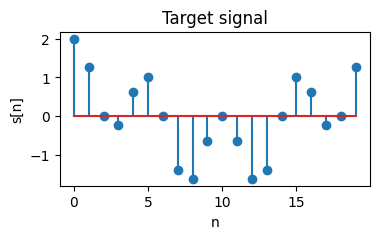

In [260]:

W = 20
omega = 0.1*pi
nvals = np.arange(0, W)

s = np.cos(omega*nvals) + np.cos(omega*nvals*4)

plt.figure(figsize=(4, 2))
plt.stem(nvals, s)
plt.title("Target signal")
plt.xlabel("n")
plt.ylabel("s[n]")
plt.show()


# 1.2 Noise-free signal generation
Using a final time $T_f=40000$ and bin size $W=20 \implies K=2000$, we now generate the noise-free signal using the target waveform. We assume that the waveform can only start at the start of each bin
$$n = 0, W, 2W, 3W, ... , KW=T_f$$
For each bin, the probability $p$ that the waveform occurs is selected to be $p=0.2$.

Then, for each $n \in [kW, (k+1)W), k=0, 1, ..., K$, the noise-free signal $z[n]$ can be represented mathematically by
$$ z[n]=\sum_{k=0}^{K-1}H[k]s[n-kW]$$
 where $H[k]=1$ with probability $p$ and $H[k]=0$ with probability $1-p$.

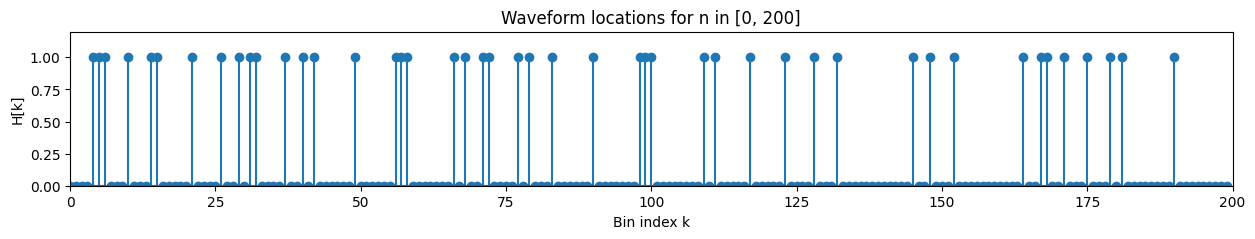

In [261]:
Tf = 40000 # final time
K = ceil(Tf / W) # number of temporal bins
p = 0.2 # probability signal occurs inside given bin

signal = np.random.rand(K, 1)
H = np.where(signal <= p, 1, 0).flatten() # Bernoulli process using random signal [0, 1)

plt.figure(figsize=(15, 2))
plt.stem(H[0:200])
plt.xlabel('Bin index k')
plt.ylabel('H[k]')
plt.title('Waveform locations for n in [0, 200]')
plt.xlim(0, 200)
plt.ylim(0, 1.2)
plt.show()

In [262]:
L = K*W
z = np.zeros((L,))
for i in range(0, K-1):
    z[i*W:(i+1)*W] = (H[i]*s)

print('Length of z:', len(z))
print('L = K·W = ', L)

Length of z: 40000
L = K·W =  40000


In [263]:
def plot_segments(z, n=700, n_rows=4, title='Noise-free signal',
                  ylabel='z[n]'):
    plt.figure(figsize=(13, n_rows * 1.2))
    for k in range(n_rows):
        plt.subplot(n_rows, 1, k+1)
        t_array = np.arange(k*n, (k+1)*n)  # Time indices for the k-th segment
        markerline, stemlines, baseline = plt.stem(t_array, z[t_array], markerfmt='.', linefmt='-', basefmt=' ')
        markerline.set_markersize(2)        # Small markers
        plt.setp(stemlines, linewidth=0.2)  # Thin lines
        plt.ylabel(ylabel)
        plt.xlim(k*n, (k+1)*n)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.xlabel('n')
    plt.suptitle(title)
    plt.show()

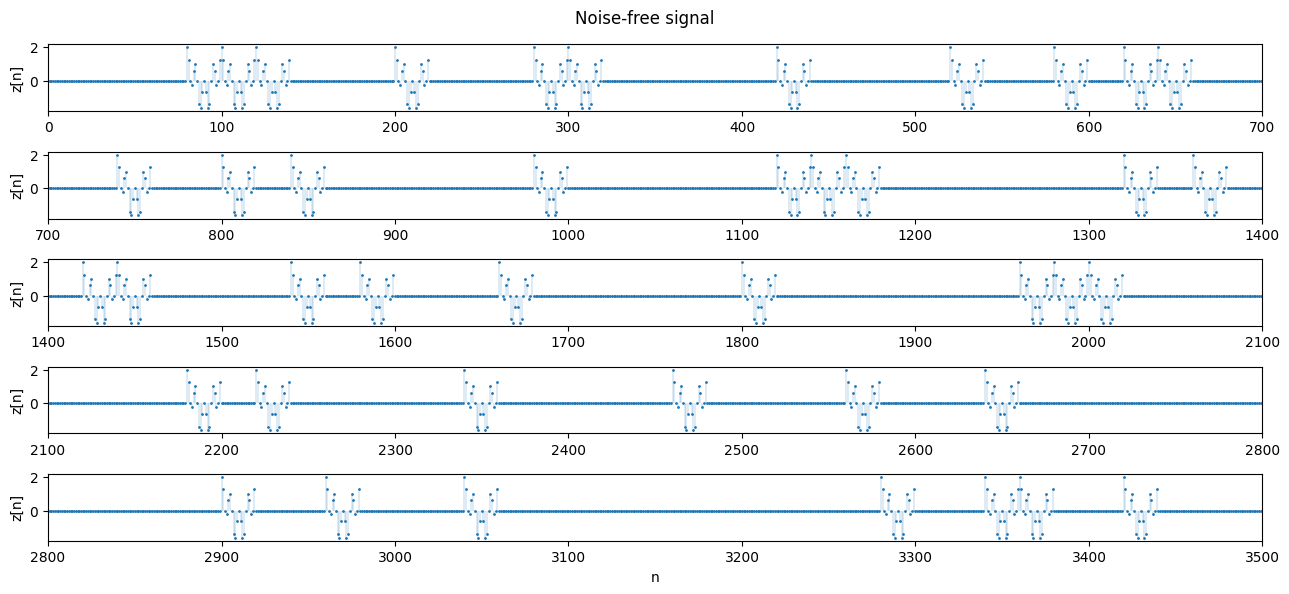

In [264]:
# Plot first 5 segments of z[n]
plot_segments(z, n_rows=5)


# 1.3 Noise generation

We now add zero-mean random Gaussian noise $w[n]$ with variance $\sigma ^2 = 1.4$. This noise can be assumed to be IID.

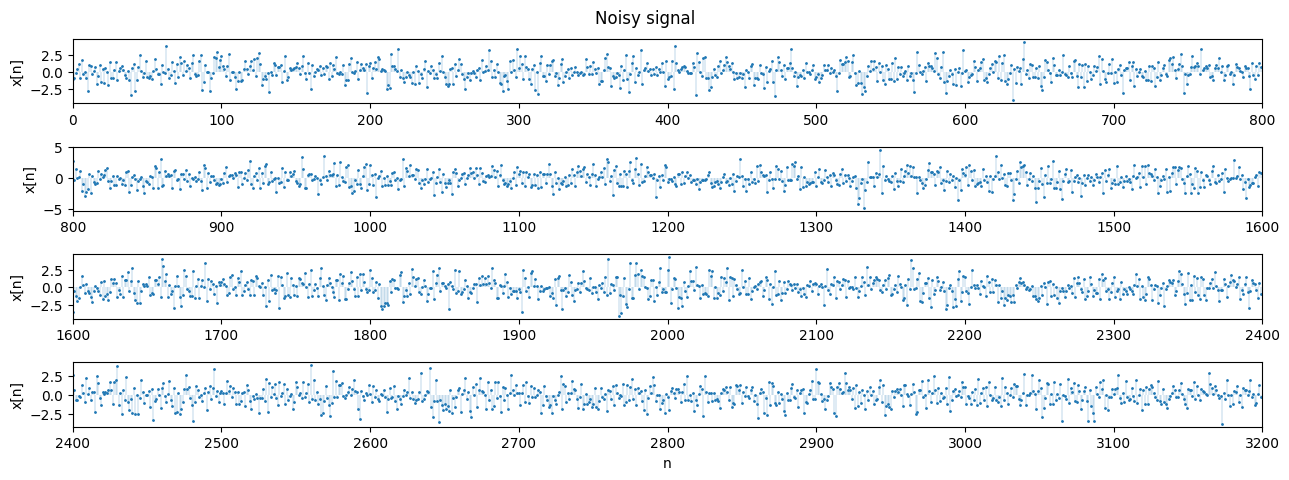

In [265]:
variance = 1.4
sigma = np.sqrt(variance)
w = np.random.normal(0, sigma, 40000)

x = np.add(z, w)
plot_segments(x, n=800, n_rows=4, title='Noisy signal', ylabel='x[n]')

# 2. Detection
Partition the signal into temporal bins, then implement a matched filter (LTI) to detect the target waveform in each slot.

# 2.1 The Matched Filter
At time bin $k$, the detection problem has two hypotheses:

$$ H=0: x[n] = w[n] $$
$$ H=1: x[n] = s[n] + w[n] $$

Which can be solved using a logarithmic likelihood ratio test (LLRT)
$$ \underbrace{\sum_{n = kW}^{(k+1)W} s[n]x[n]}_{MF} \quad \overset{D=1}{\underset{D=0}{\gtrless}} \quad \tilde{\eta} $$

where $\displaystyle \tilde{\eta}=\sigma^2 \log(\eta) + \frac{1}{2}\sum_{n = kW}^{(k+1)W} s[n]^2$ depends on the threshold parameter $\eta$, which is determined by the type of detector (e.g. ML, MAP, NP, etc).



In [266]:
X = np.reshape(x, (K, W))

print(X.shape)

(2000, 20)


We can rewrite the LLRT by defining the test statistic $T_k=\mathbf{x}_k^T\mathbf{s}$ and target signal energy $\displaystyle E = \sum_{n = kW}^{(k+1)W}s[n]^2$. If we implement an ML detector, $\eta=1 \implies \log(\eta)=0$. Then, the LLRT becomes

$$ T_k \gtrless \frac{1}{2}E $$

In [267]:
E = np.sum(s**2)
eta_tilde = 0.5*E

T = np.dot(X, s)
D = np.where(T > eta_tilde, 1, 0)

# Check sizes and values
print('Signal power E:', E)
print('Threshold eta_tilde:', eta_tilde)
print('Shape of H:', H.shape)
print('Shape of T:', T.shape)
print('Shape of D:', D.shape)
print('First 10 values of H:', H[:10])
print('First 10 values of D:', D[:10])
print('First 10 values of T:', T[:10])

Signal power E: 20.0
Threshold eta_tilde: 10.0
Shape of H: (2000,)
Shape of T: (2000,)
Shape of D: (2000,)
First 10 values of H: [0 0 0 0 1 1 1 0 0 0]
First 10 values of D: [0 0 0 0 1 1 1 0 0 0]
First 10 values of T: [-6.5133609  -8.46987125  9.04217375 -5.33902768 23.39117615 14.72106205
 20.28379332 -2.3278463  -3.70028707 -2.62882768]


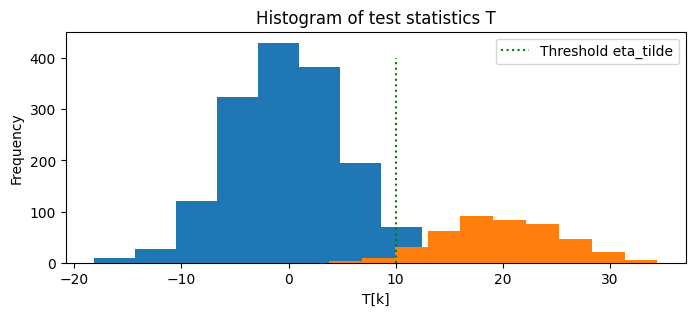

In [268]:
# Plot the histogram of the test statistics T for the cases H[k] = 0 and H[k] = 1
plt.figure(figsize=(8, 3))
plt.hist(T[H == 0])
plt.hist(T[H == 1])
# Locate the threshold eta_tilde on the histogram
plt.plot([eta_tilde, eta_tilde], [0, 400], 'g:', label='Threshold eta_tilde')
plt.title('Histogram of test statistics T')
plt.xlabel('T[k]')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# 2.2 Detector analysis and ROC curve
We now would like to analyze our ML detector's performance using an ROC curve. To do this, we compute both the False Alarm and Detection probabilities.

In [269]:
num_FA = np.sum(D[H == 0])
num_D  = np.sum(D[H == 1])

prob_FA = num_FA / np.sum(H == 0)
prob_D  = num_D  / np.sum(H == 1)

print('Number of false alarms n_FA:', num_FA)
print('Number of detections n_D:', num_D)
print('False alarm probability P_FA:', prob_FA)
print('Detection probability P_D:', prob_D)

Number of false alarms n_FA: 60
Number of detections n_D: 415
False alarm probability P_FA: 0.03816793893129771
Detection probability P_D: 0.969626168224299


In [270]:
def Q(a):
  return 0.5*erfc(a/np.sqrt(2))

In [271]:
prob_FA_theoretical = Q(eta_tilde / (np.sqrt(E*(variance**2))))
prob_D_theoretical = Q((eta_tilde - E) / (np.sqrt(E*(variance**2))))
print('Theoretical false alarm probability P_FA:', prob_FA_theoretical)
print('Theoretical detection probability P_D:', prob_D_theoretical)

Theoretical false alarm probability P_FA: 0.055111523177432675
Theoretical detection probability P_D: 0.9448884768225674


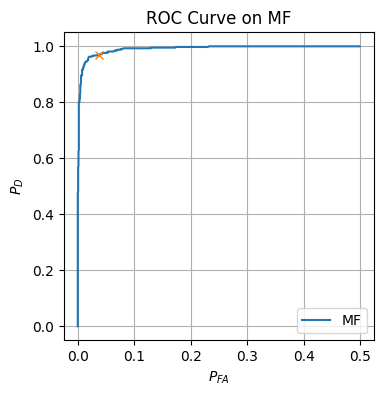

In [272]:
eta_tilde_vals = np.linspace(0, 2*E, 1000)

prob_FA_vals_MF = np.zeros((len(eta_tilde_vals),))
prob_D_vals_MF  = np.zeros((len(eta_tilde_vals),))

for i in range(len(eta_tilde_vals)):
  D = np.where(T > eta_tilde_vals[i], 1, 0)
  prob_FA_vals_MF[i] = np.sum(D[H == 0]) / np.sum(H == 0)
  prob_D_vals_MF[i]  = np.sum(D[H == 1])  / np.sum(H == 1)

plt.figure(figsize=(4, 4))
plt.plot(prob_FA_vals_MF, prob_D_vals_MF, label=r'MF')
plt.plot(prob_FA, prob_D, marker='x')
plt.legend()
plt.xlabel(r'$P_{FA}$')
plt.ylabel(r'$P_D$')
plt.title('ROC Curve on MF')
plt.grid()
plt.show()

# 2.3 Matched filter implementation
We now convolve (using ```np.convolve```) the signal with the linear matched filter to obtain the same results as the bin-by-bin detector implemented above.

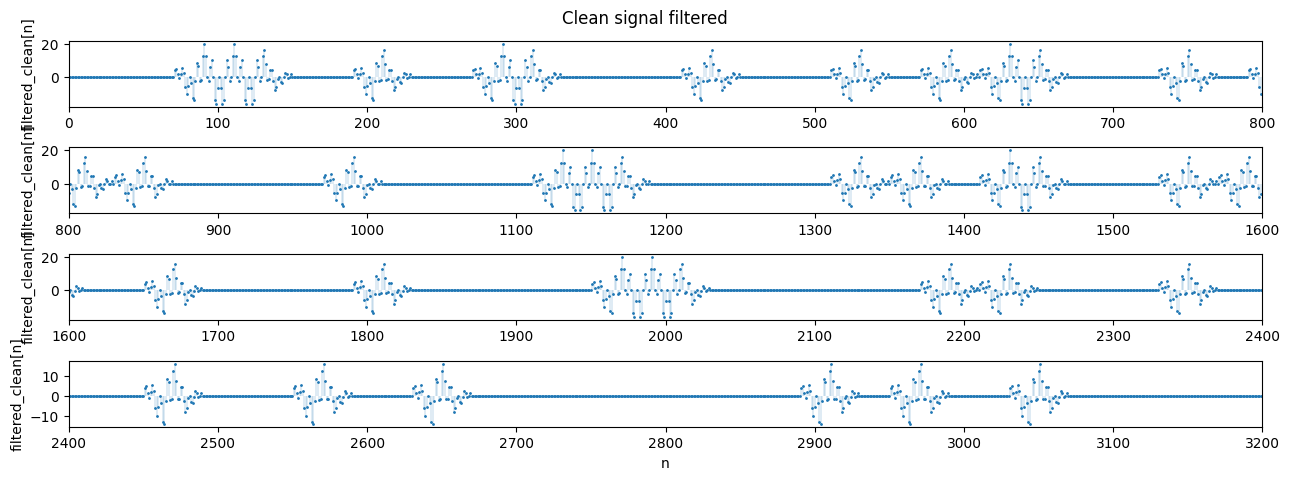

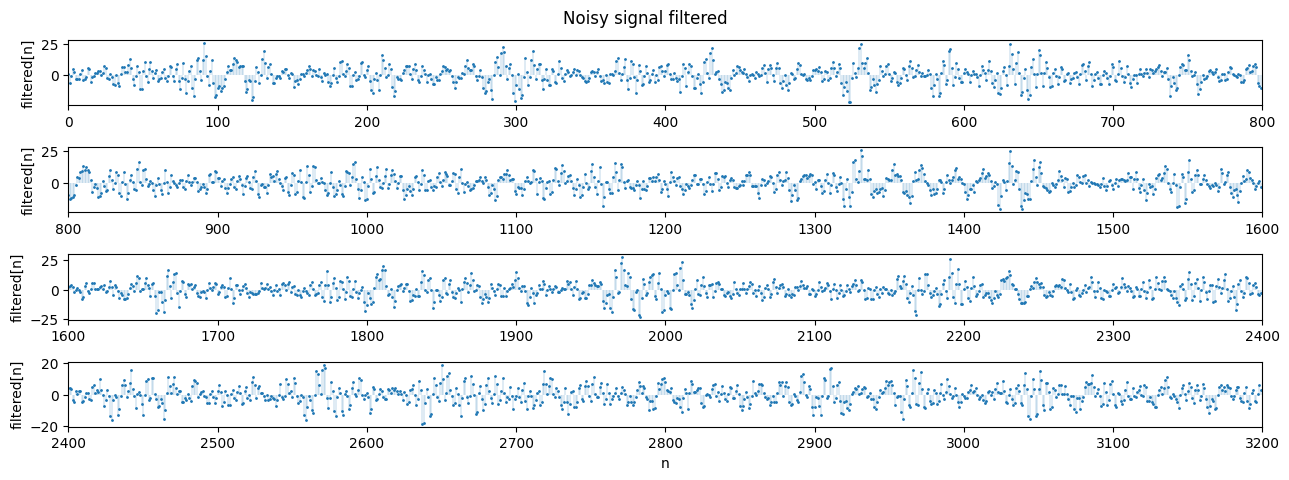

First 10 values of H: [0 0 0 0 1 1 1 0 0 0]
First 10 values of D: [0 0 0 0 0 0 0 0 0 0]
First 10 values of T: [-6.5133609  -8.46987125  9.04217375 -5.33902768 23.39117615 14.72106205
 20.28379332 -2.3278463  -3.70028707 -2.62882768]


In [273]:
filtered_clean = np.convolve(z, s, mode='same')

filtered = np.convolve(x, s, mode='same')

plot_segments(filtered_clean, n=800, n_rows=4, title='Clean signal filtered', ylabel='filtered_clean[n]')
plot_segments(filtered, n=800, n_rows=4, title='Noisy signal filtered', ylabel='filtered[n]')

D_filtered = np.where(filtered > eta_tilde, 1, 0)
print('First 10 values of H:', H[:10])
print('First 10 values of D:', D[:10])
print('First 10 values of T:', T[:10])

# 3. Detection Under Impulsive Noise
When the signal is corrupted with impulsive noise  (i.e. combined Gaussian noise with noticeable impulses), a matched filter performs markedly worse. This setup is typical of power-line communication (PLC) systems, motivating an improved filter.

Here, we assume that the noise can be represented by a combination of Gaussian noise defined by zero-mean probability density functions (PDFs) described by respective variances $\sigma_1^2, \sigma_2^2$ where $\sigma_2^2 \gg \sigma_1^2$. The noise PDF can be expressed as

$$ p_W(w) = \frac{1 - \epsilon}{\sqrt{2 \pi \sigma_{1}^2}}\exp \left(-\frac{w^2}{2\sigma_1^2} \right) + \frac{\epsilon}{\sqrt{2 \pi \sigma_{2}^2}} \exp \left(-\frac{w^2}{2\sigma_2^2} \right) $$

where the probability of the large impulse noise occurring is $\epsilon$ and the probability of the background noise occurring is $1-\epsilon$.

For this problem, it is necessary to improve our LLRT. We use the **generative** function $g(x[n])$ to improve the robustness of the filter, where

$$ g(x[n]) = \frac{p'_W(x[n])}{p_W(x[n])} $$

In [274]:
def impulsive_noise(epsilon, var1, var2, N):
  w = np.zeros((N,))

  noise_choice = np.random.rand(N) <= epsilon

  w[noise_choice] = np.random.normal(0, np.sqrt(var2), np.sum(noise_choice))
  w[~noise_choice] = np.random.normal(0, np.sqrt(var1), np.sum(~noise_choice))
  return w

In [275]:
def gFunction(x, var1, var2, epsilon):
  p_prime = ((1 - epsilon) * (-2 * x / (2*var1**2)) * (1 / (np.sqrt(2 * np.pi * var1))) * np.exp(-(x**2)/(2 * np.pi * var1))) + ((epsilon) * (-2 * x / (2*var2**2)) * (1 / (np.sqrt(2 * np.pi * var2))) * np.exp(-(x**2)/(2 * np.pi * var2)))
  p = ((1 - epsilon) * (1 / (np.sqrt(2 * np.pi * var1))) * np.exp(-(x**2)/(2 * np.pi * var1))) + ((epsilon) * (1 / (np.sqrt(2 * np.pi * var2))) * np.exp(-(x**2)/(2 * np.pi * var2)))
  g = -p_prime / p
  return g

# 3.1 Simple Matched Filter vs Updated Generative Model
We test the simple matched filter from before on the new impulsive noise and compare the results to the results from the updated generative filter model. We use parameters

$$ \epsilon = 0.15 $$
$$ \sigma_1^2 = 1 $$
$$ \sigma_2^2 = 50 $$

to define the impulsive noise, which we visualize below compared to the original Gaussian noise.

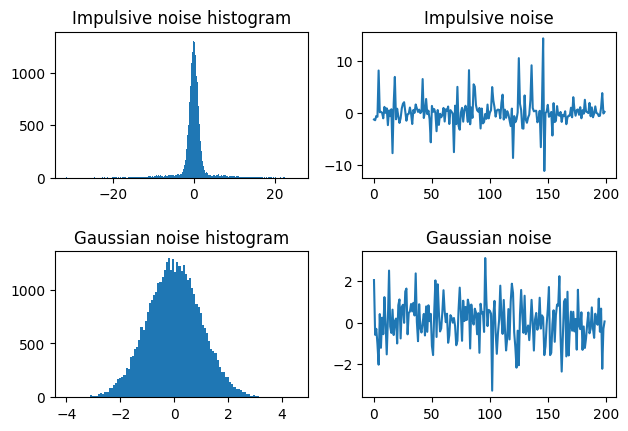

In [276]:
w_impulsive = impulsive_noise(0.15,1,50,40000)
w_Gaussian = np.sqrt(1)*np.random.randn(40000)

plt.figure()
plt.subplot(221)
plt.hist(w_impulsive, bins='auto')
plt.title('Impulsive noise histogram')
plt.subplot(222)
plt.plot(w_impulsive[0:200])
plt.title('Impulsive noise')
plt.subplot(223)
plt.hist(w_Gaussian, bins='auto')
plt.title('Gaussian noise histogram')
plt.subplot(224)
plt.plot(w_Gaussian[0:200])
plt.title('Gaussian noise')
plt.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=2.0)
plt.show()

We now implement the generative filter decision maker and compare it to the matched filter from earlier on the impulsive noise.

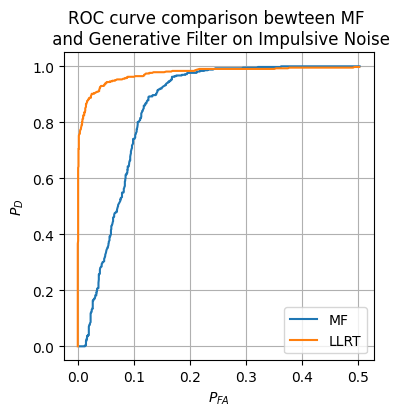

In [277]:
epsilon = 0.15
var1 = 1
var2 = 50

# add noise
x_hat = z + w_impulsive
X_hat = np.reshape(x_hat, (K, W))

g = gFunction(x_hat, var1, var2, epsilon)
G = np.reshape(g, (K, W))

T_hat_MF = np.dot(X_hat, s) # MF filter from before
T_hat_LLRT = np.dot(G, s)

prob_FA_vals_hat_MF = np.zeros((len(eta_tilde_vals),))
prob_D_vals_hat_MF = np.zeros((len(eta_tilde_vals),))
prob_FA_vals_hat_LLRT = np.zeros((len(eta_tilde_vals),))
prob_D_vals_hat_LLRT  = np.zeros((len(eta_tilde_vals),))

for i in range(len(eta_tilde_vals)):
  D_MF = np.where(T_hat_MF > eta_tilde_vals[i], 1, 0)
  D_LLRT = np.where(T_hat_LLRT > eta_tilde_vals[i], 1, 0)

  prob_FA_vals_hat_MF[i] = np.sum(D_MF[H == 0]) / np.sum(H == 0)
  prob_D_vals_hat_MF[i]  = np.sum(D_MF[H == 1])  / np.sum(H == 1)

  prob_FA_vals_hat_LLRT[i] = np.sum(D_LLRT[H == 0]) / np.sum(H == 0)
  prob_D_vals_hat_LLRT[i]  = np.sum(D_LLRT[H == 1])  / np.sum(H == 1)

plt.figure(figsize=(4, 4))
plt.plot(prob_FA_vals_hat_MF, prob_D_vals_MF,  label=r'MF')
plt.plot(prob_FA_vals_hat_LLRT, prob_D_vals_hat_LLRT, label=r'LLRT')
plt.legend()
plt.xlabel(r'$P_{FA}$')
plt.ylabel(r'$P_D$')
plt.title('ROC curve comparison bewteen MF \n and Generative Filter on Impulsive Noise')
plt.grid()
plt.show()

Clearly, the updated LLRT is much more robust to this new impulsive noise.